<a href="https://colab.research.google.com/github/krantik00/Training_Notebook1/blob/main/python_search_dataframe_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning Objectives

- Implement ReAct agents using `langchain` abstractions

# Setup

In [3]:
!pip install groq \
                langchain\
                langchain-groq \
                langchain-experimental==0.0.52 \
                langchainhub==0.1.15 \
                duckduckgo_search==5.3.1b1 \
                google-search-results \
                langchain-community

  Using cached groq-1.5.0-py3-none-any.whl.metadata (16 kB)
  Using cached langchain_experimental-0.0.52-py3-none-any.whl.metadata (2.1 kB)
  Using cached langchainhub-0.1.15-py3-none-any.whl.metadata (621 bytes)
  Using cached duckduckgo_search-5.3.1b1-py3-none-any.whl.metadata (18 kB)
  Using cached google_search_results-2.4.2.tar.gz (18 kB)
  Preparing metadata (setup.py) ... done
  Using cached langchain_community-0.4.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached langchain_core-0.1.53-py3-none-any.whl.metadata (5.9 kB)
  Using cached dataclasses_json-0.6.7-py3-none-any.whl.metadata (25 kB)
  Using cached langchain_community-0.0.38-py3-none-any.whl.metadata (8.7 kB)
  Using cached langsmith-0.1.147-py3-none-any.whl.metadata (14 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached tenacity-8.5.0-py3-none-any.whl.metadata (1.2 kB)
  Using cached groq-0.37.1-py3-none-any.whl.metadata (16 kB)
INFO: pip is lookin

In [3]:
import json

import pandas as pd

from langchain import hub

from langchain_groq import ChatGroq

from langchain.agents.agent_types import AgentType
from langchain.agents import Tool, AgentExecutor, create_react_agent

from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
from langchain_experimental.utilities import PythonREPL
from langchain.tools import DuckDuckGoSearchRun, yahoo_finance_news
from langchain_community.utilities import GoogleSerperAPIWrapper

from sklearn.datasets import fetch_openml

from google.colab import drive, userdata

In [24]:
openai_api_key = userdata.get('GROQ_API_KEY')
serper_api_key = userdata.get('SERPER_API_KEY')

In [45]:
gpt54mini = ChatGroq(
    model='llama-3.1-8b-instant',
    api_key=openai_api_key,
    temperature=0
)

In [46]:
gpt4 = ChatGroq(
    model='llama-3.3-70b-versatile',
    api_key=openai_api_key,
    temperature=0
)

# `LangChain` implements ReAct

 ## Overview

One popular implementation of the ReAct framework is in the `langchain` package that offers several abstractions for different parts of the ReAct paradigm. LangChain also provides out-of-the box solutions to common problems solved by LLM Agents (e.g., Retrieval-Augmented Generation).

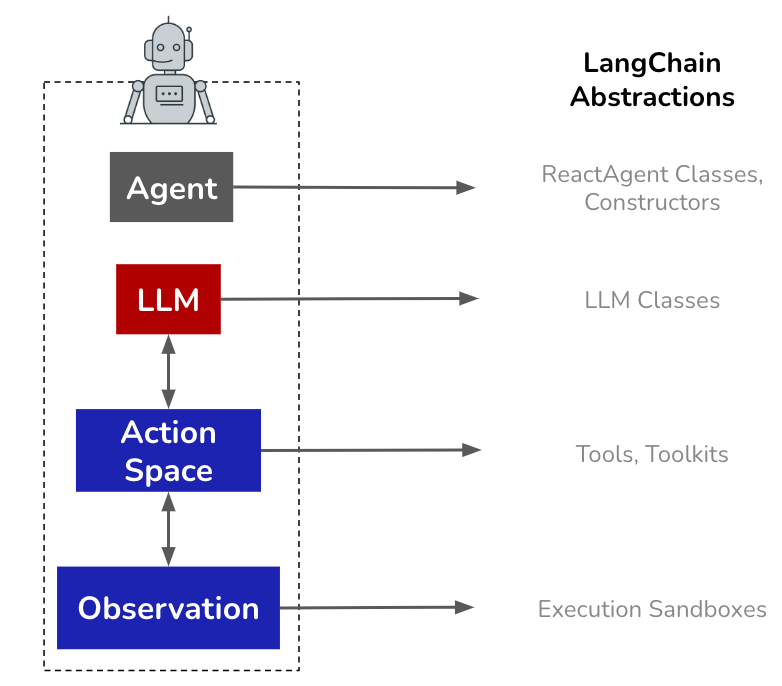

## Tools

An important abstraction that allows `langchain` agents to *act* are `Tool` classes. Each tool allows the agent to execute a specific action as a chain. Let us look at two such tools - `PythonREPL` & `DuckDuckGoSearchRun`.   

In [47]:
python_repl = PythonREPL()

In [48]:
python_repl.run("print('Hello World! I am a langchain tool that allows running arbitrary Python code')")

'Hello World! I am a langchain tool that allows running arbitrary Python code\n'

In [49]:
python_repl.schema()

{'title': 'PythonREPL',
 'description': 'Simulates a standalone Python REPL.',
 'type': 'object',
 'properties': {'_globals': {'title': ' Globals', 'type': 'object'},
  '_locals': {'title': ' Locals', 'type': 'object'}}}

We can wrap this REPL as a tool that can be used by an agent like so:

In [50]:
repl_tool = Tool(
    name="python_repl",
    description="A Python shell used to execute python commands. Input should be a valid python command.",
    func=python_repl.run,
)

We can now invoke this tool (just as an agent would do).

In [51]:
repl_tool.invoke('print("Hello World!")')

'Hello World!\n'

In [52]:
serper_search = GoogleSerperAPIWrapper(serper_api_key=serper_api_key)

In [53]:
serper_search.run("Who is the founder of Tesla?")

"Tesla: Automotive company. Tesla Customer service chat: Online Chat. Tesla CEO: Elon Musk (Oct 2008–). Tesla CFO: Vaibhav Taneja. Tesla Headquarters: Austin, TX. Tesla Founded: July 1, 2003, San Carlos, CA. Tesla Founders: Elon Musk, Martin Eberhard, JB Straubel, and more. Its name is a tribute to the inventor and electrical engineer Nikola Tesla. In February 2004, Elon Musk led Tesla's first funding round and became the company's ... Tesla Motors was founded as an electric carmaker by engineers Martin Eberhard and Marc Tarpenning in 2003. Elon Musk, co-founder of X.com, ... Elon Musk co-founded and leads Tesla, SpaceX, Neuralink and The Boring Company. As the co-founder and CEO of Tesla, Elon leads all product design, ... Tesla was incorporated in July 2003 by Martin Eberhard and Marc Tarpenning as Tesla Motors. Please substantiate the reason for your disagreement ... Tesla's Forgotten Founder Speaks Out – Exclusive w/ Martin Eberhard · Comments. 3.4K. Martin is a historic figure, an

In [54]:
search_tool = Tool(
    name="serper_search",
    description="An interface to the Serper search engine. Input should be a string.",
    func=serper_search.run,
)

We can now invoke the search tool (like an agent would do).

In [55]:
search_tool.invoke("Who is the founder of Tesla?")

"Tesla: Automotive company. Tesla Customer service chat: Online Chat. Tesla CEO: Elon Musk (Oct 2008–). Tesla CFO: Vaibhav Taneja. Tesla Headquarters: Austin, TX. Tesla Founded: July 1, 2003, San Carlos, CA. Tesla Founders: Elon Musk, Martin Eberhard, JB Straubel, and more. Its name is a tribute to the inventor and electrical engineer Nikola Tesla. In February 2004, Elon Musk led Tesla's first funding round and became the company's ... Tesla Motors was founded as an electric carmaker by engineers Martin Eberhard and Marc Tarpenning in 2003. Elon Musk, co-founder of X.com, ... Elon Musk co-founded and leads Tesla, SpaceX, Neuralink and The Boring Company. As the co-founder and CEO of Tesla, Elon leads all product design, ... Tesla was incorporated in July 2003 by Martin Eberhard and Marc Tarpenning as Tesla Motors. Please substantiate the reason for your disagreement ... Tesla's Forgotten Founder Speaks Out – Exclusive w/ Martin Eberhard · Comments. 3.4K. Martin is a historic figure, an

With this overall framework in place, let us now create a few agents and see how the `langchain` abstractions work in practise.

## Python Agent

### Initialization

In [56]:
python_repl = PythonREPL()

In [57]:
repl_tool = Tool(
    name="python_repl",
    description="A Python shell used to execute python commands. Input should be a valid python command.",
    func=python_repl.run,
)

In [58]:
react_prompt = hub.pull("hwchase17/react")

In [59]:
react_agent = create_react_agent(
    llm=gpt54mini,
    tools=[repl_tool],
    prompt=react_prompt
)

In [60]:
react_agent_executor = AgentExecutor(
    agent=react_agent,
    tools=[repl_tool],
    verbose=True
)

### Execution

In [61]:
sample_queries = [
    "If $ 450 amounts to $ 630 in 6 years, what will it amount to in 2 years at the same interest rate?",
    "The stock price of the shares of a certain company A closes at $ 117.25 on August 1st whose strike price is $100. The stock expires on November 1st. There are no dividends that need to be paid till the expiry date and the risk-free annual interest rate is 8.5%. If the standard deviation of the volatility of the stock returns is 0.8445, calculate the price of the call option using the Black-Scholes model formula."
]

In [62]:
# @title Enter your query
user_input = "If $ 450 amounts to $ 630 in 6 years, what will it amount to in 2 years at the same interest rate?" # @param {type:"string"}

response = react_agent_executor.invoke(
    {
        'input': user_input
    }
)

print(response['output'])



> Entering new AgentExecutor chain...
Thought: To solve this problem, we need to find the interest rate first. We can use the formula for simple interest: A = P(1 + rt), where A is the amount, P is the principal, r is the interest rate, and t is the time.

Action: Calculate the interest earned in 6 years.
Action Input: `interest_earned = 630 - 450`Calculate the interest earned in 6 years. is not a valid tool, try one of [python_repl].Question: If $ 450 amounts to $ 630 in 6 years, what will it amount to in 2 years at the same interest rate?
Thought: To solve this problem, we need to find the interest rate first. We can use the formula for simple interest: A = P(1 + rt), where A is the amount, P is the principal, r is the interest rate, and t is the time.

Action: python_repl
Action Input: `interest_earned = 630 - 450`SyntaxError('invalid syntax', ('<string>', 1, 1, '`interest_earned = 630 - 450`\n', 1, 2))Question: If $ 450 amounts to $ 630 in 6 years, what will it amount to in 2 yea

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.1-8b-instant` in organization `org_01kpgexsdkects7fta20pqa39k` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 3673, Requested 2411. Please try again in 840ms. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

## Search Agent

### Initialization

In [63]:
serper_search = GoogleSerperAPIWrapper(serper_api_key=serper_api_key)

In [64]:
search_tool = Tool(
    name="serper_search",
    description="An interface to the Serper search engine. Input should be a string.",
    func=serper_search.run,
)

In [65]:
react_prompt = hub.pull("hwchase17/react")

In [66]:
react_agent = create_react_agent(
    llm=gpt4,
    tools=[search_tool, repl_tool],
    prompt=react_prompt
)

In [67]:
react_agent.get_prompts()

[PromptTemplate(input_variables=['agent_scratchpad', 'input'], partial_variables={'tools': 'serper_search: An interface to the Serper search engine. Input should be a string.\npython_repl: A Python shell used to execute python commands. Input should be a valid python command.', 'tool_names': 'serper_search, python_repl'}, metadata={'lc_hub_owner': 'hwchase17', 'lc_hub_repo': 'react', 'lc_hub_commit_hash': 'd15fe3c426f1c4b3f37c9198853e4a86e20c425ca7f4752ec0c9b0e97ca7ea4d'}, template='Answer the following questions as best you can. You have access to the following tools:\n\n{tools}\n\nUse the following format:\n\nQuestion: the input question you must answer\nThought: you should always think about what to do\nAction: the action to take, should be one of [{tool_names}]\nAction Input: the input to the action\nObservation: the result of the action\n... (this Thought/Action/Action Input/Observation can repeat N times)\nThought: I now know the final answer\nFinal Answer: the final answer to th

In [68]:
react_agent_executor = AgentExecutor(
    agent=react_agent,
    tools=[search_tool, repl_tool],
    verbose=True,
    handle_parsing_errors=True
)

In [ ]:
# @title Enter your query
user_input = "I want to plan a vacation to Norway for 4 days please help me plan one within a budget of 3000 dollars taking into account hotels tours etc excluding flights all starting from Oslo ?" # @param {type:"string"}

response = react_agent_executor.invoke(
    {
        'input': user_input
    }
)

print(response['output'])



> Entering new AgentExecutor chain...
First, I need to find out the average cost of hotels in Oslo, Norway for 4 days. 
Action: serper_search
Action Input: "average cost of hotels in Oslo Norway for 4 days"Find 666 of the best hotels in Oslo in 2026. Compare room rates, hotel reviews and availability. Most hotels are fully refundable. Missing: cost | Show results with:cost. Hotels are cheapest in Oslo in December, with average rates of $158/night. In comparison, June is the most expensive month, with prices at $249/night. View deals from $81 per night, see photos and read reviews for the best Oslo hotels from travelers like you - then compare today's ... Central Oslo about 2000 per night. A bit out 1000-2000 per night, can get under 1000 as well from time to time. Missing: 4 | Show results with:4. Seeing as the average price for a hotel in Oslo in $199/night, a good deal for a nightly rate on a hotel room would be anything under $199/night. If you're ... With average hotel prices sta

## DataFrame Agent

### Initialization

In [69]:
bank_data, _ = fetch_openml(data_id=43718, return_X_y=True, parser="auto")

In [70]:
bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [71]:
bank_data.sample(3)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
7158,36,unemployed,divorced,primary,no,0,no,no,telephone,4,jul,304,3,-1,0,unknown,no
9366,53,entrepreneur,married,secondary,no,288,no,no,unknown,6,may,69,1,-1,0,unknown,no
8367,30,blue-collar,divorced,secondary,yes,457,yes,no,unknown,20,jun,115,20,-1,0,unknown,no


In [73]:
gpt35 = ChatGroq(
    model='llama-3.1-8b-instant',
    api_key=openai_api_key,
    temperature=0
)
pandas_agent = create_pandas_dataframe_agent(
    llm=gpt35,
    df=bank_data,
    verbose=True,
    agent_type=AgentType.OPENAI_FUNCTIONS
)

### Execution

In [74]:
sample_inputs = [
    "How many customers have defaulted on loans?",
    "What is the average balance maintained by our customers?",
    "How many customers have subscribed to a term deposit?",
    "How many customers will default next month?",
    "What is the relationship between loan default and monthly balance?",
    "Do customers who default maintain a low balance?"
]



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "df.groupby('education')['balance'].mean().plot(kind='bar')"}`


Axes(0.125,0.11;0.775x0.77)The bar chart shows the average balance for each education level. The x-axis represents the education level and the y-axis represents the average balance. The bar chart is not visible here, but running the provided code in a Python environment with graphical capabilities will display it.

> Finished chain.
The bar chart shows the average balance for each education level. The x-axis represents the education level and the y-axis represents the average balance. The bar chart is not visible here, but running the provided code in a Python environment with graphical capabilities will display it.


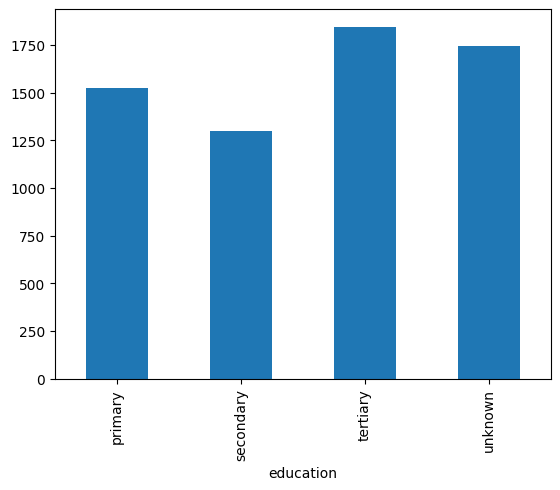

In [ ]:
# @title Enter your query

user_input = "Which education level has the highest average balance show as a bar chart." # @param {type:"string"}
response = pandas_agent.invoke(user_input,
    handle_parsing_errors=True)
print(response['output'])